# 02 Spatial RGB Baseline Model using ResNet18

## CSE 445: Machine Learning Project

**Project Title:** Robust AI-Generated Image Detection using Hybrid Spatial–Frequency Analysis  
**Student:** Zawed Bin Tariq  
**Student ID:** 2232811642  
**Instructor:** Dr. Mohammad Abdul Qayum  

---

## Notebook Objective

This notebook trains the first baseline deep learning model for AI-generated image detection.

The model uses only **spatial-domain RGB image information**.  
No frequency-domain features are used in this notebook.

This baseline is important because future models will be compared against it:

1. RGB Spatial Model
2. Frequency-Domain Model
3. Hybrid Spatial–Frequency Model
4. Ensemble Models

# 1. Baseline Model Motivation

A baseline model provides the first reference point for evaluating the project.

In this notebook, a pretrained **ResNet18** model is fine-tuned for binary image classification.

## Why ResNet18?

ResNet18 is selected because:

- It is a strong convolutional neural network baseline.
- It uses residual connections to improve deep network training.
- It is computationally efficient for Kaggle GPU.
- It is suitable for transfer learning on small-to-medium image datasets.

## Classification Labels

| Label | Class |
|---:|---|
| 0 | Real |
| 1 | AI-generated / Fake |

# 2. Experimental Setup

The same dataset sampling and train/validation/test split from Notebook 1 is recreated using a fixed random seed.

Dataset subset:

| Class | Images |
|---|---:|
| Real | 2000 |
| Fake | 2000 |
| **Total** | **4000** |

Split:

| Split | Images |
|---|---:|
| Training | 2400 |
| Validation | 800 |
| Testing | 800 |

Each split is balanced between real and fake images.

In [1]:
# ============================================================
# 3. Import Required Libraries
# ============================================================

import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

print("Libraries imported successfully.")
print("PyTorch version:", torch.__version__)

Libraries imported successfully.
PyTorch version: 2.10.0+cu128


In [2]:
# ============================================================
# 4. Device Configuration
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available. Training will run on CPU.")

Using device: cuda
GPU name: Tesla T4


In [3]:
# ============================================================
# 4. Device Configuration
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available. Training will run on CPU.")

Using device: cuda
GPU name: Tesla T4


In [4]:
# ============================================================
# 4. Device Configuration
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available. Training will run on CPU.")

Using device: cuda
GPU name: Tesla T4


In [5]:
# ============================================================
# 5. Reproducibility Setup
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed fixed at: {SEED}")

Random seed fixed at: 42


# 3. Dataset Loading and Balanced Split

The dataset is loaded from Kaggle input storage.

To avoid path-label errors, class labels are detected using the image's immediate parent folder:

- `real/` → Real image
- `fake/` → AI-generated image

In [6]:
# ============================================================
# 6. Load Image Paths - Faster Version
# ============================================================

dataset_root = Path("/kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images")

image_extensions = {".jpg", ".jpeg", ".png", ".webp"}

real_paths = []
fake_paths = []

for split_folder in ["train", "test"]:
    real_dir = dataset_root / split_folder / "real"
    fake_dir = dataset_root / split_folder / "fake"
    
    real_paths.extend([
        p for p in real_dir.iterdir()
        if p.suffix.lower() in image_extensions
    ])
    
    fake_paths.extend([
        p for p in fake_dir.iterdir()
        if p.suffix.lower() in image_extensions
    ])

all_image_paths = real_paths + fake_paths

print(f"Total image files found: {len(all_image_paths)}")
print(f"Real images found: {len(real_paths)}")
print(f"Fake images found: {len(fake_paths)}")

Total image files found: 60000
Real images found: 30000
Fake images found: 30000


In [7]:
# ============================================================
# 7. Balanced Sampling: 2000 Real + 2000 Fake
# ============================================================

N_REAL = 2000
N_FAKE = 2000

real_sample = random.sample(real_paths, N_REAL)
fake_sample = random.sample(fake_paths, N_FAKE)

real_df = pd.DataFrame({
    "image_path": [str(p) for p in real_sample],
    "label": 0,
    "class_name": "real"
})

fake_df = pd.DataFrame({
    "image_path": [str(p) for p in fake_sample],
    "label": 1,
    "class_name": "fake"
})

df = pd.concat([real_df, fake_df], ignore_index=True)
df = shuffle(df, random_state=SEED).reset_index(drop=True)

print("Balanced dataframe created.")
print(df["class_name"].value_counts())

Balanced dataframe created.
class_name
real    2000
fake    2000
Name: count, dtype: int64


In [8]:
# ============================================================
# 8. Train/Validation/Test Split
# ============================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.40,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Dataset split completed.")

print("\nTrain size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

print("\nClass distribution:")
print("Train:")
print(train_df["class_name"].value_counts())
print("\nValidation:")
print(val_df["class_name"].value_counts())
print("\nTest:")
print(test_df["class_name"].value_counts())

Dataset split completed.

Train size: 2400
Validation size: 800
Test size: 800

Class distribution:
Train:
class_name
real    1200
fake    1200
Name: count, dtype: int64

Validation:
class_name
real    400
fake    400
Name: count, dtype: int64

Test:
class_name
real    400
fake    400
Name: count, dtype: int64


# 4. Image Transformations

The images are resized to `224 × 224` because ResNet18 expects ImageNet-style input dimensions.

Training images use basic data augmentation:

- Random horizontal flip
- Random rotation
- Color jitter

Validation and test images use only deterministic preprocessing.

In [9]:
# ============================================================
# 9. Image Transformations
# ============================================================

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image transformations defined.")

Image transformations defined.


In [10]:
# ============================================================
# 9. Image Transformations
# ============================================================

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image transformations defined.")

Image transformations defined.


In [11]:
# ============================================================
# 10. PyTorch Dataset Class
# ============================================================

class AIImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        image_path = self.dataframe.loc[idx, "image_path"]
        label = int(self.dataframe.loc[idx, "label"])
        
        image = Image.open(image_path).convert("RGB")
        
        if self.transform is not None:
            image = self.transform(image)
        
        return image, label

print("PyTorch Dataset class created.")

PyTorch Dataset class created.


In [12]:
# ============================================================
# 11. Create DataLoaders
# ============================================================

BATCH_SIZE = 32

train_dataset = AIImageDataset(train_df, transform=train_transform)
val_dataset = AIImageDataset(val_df, transform=eval_transform)
test_dataset = AIImageDataset(test_df, transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created successfully.")
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

DataLoaders created successfully.
Training batches: 75
Validation batches: 25
Testing batches: 25


In [13]:
# ============================================================
# 12. DataLoader Sanity Check
# ============================================================

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Sample labels:", labels[:10].tolist())

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Sample labels: [0, 1, 1, 0, 1, 0, 1, 1, 0, 0]


# 5. ResNet18 Baseline Model

A pretrained ResNet18 model is used as the spatial-domain RGB baseline.

The original ResNet18 model was trained on ImageNet with 1000 output classes.  
For this binary classification task, the final fully connected layer is replaced with a new classifier that outputs two classes:

- Real
- Fake / AI-generated

In [14]:
# ============================================================
# 13. ResNet18 Model Setup
# ============================================================

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Replace final classification layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

print("ResNet18 model loaded successfully.")
print("Final layer:", model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


ResNet18 model loaded successfully.
Final layer: Linear(in_features=512, out_features=2, bias=True)


In [15]:
# ============================================================
# 14. Loss Function and Optimizer
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("Loss function and optimizer defined.")

Loss function and optimizer defined.


# 6. Training and Validation Functions

The model is trained using cross-entropy loss.

For each epoch:

1. The model is trained on the training set.
2. The model is evaluated on the validation set.
3. Training loss, validation loss, and validation accuracy are recorded.

The validation set is not used for learning.  
It is only used to monitor model performance and overfitting.

In [16]:
# ============================================================
# 15. Training Function
# ============================================================

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        
        _, preds = torch.max(outputs, 1)
        correct_predictions += (preds == labels).sum().item()
        total_samples += labels.size(0)
    
    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    
    return epoch_loss, epoch_accuracy

In [17]:
# ============================================================
# 16. Evaluation Function
# ============================================================

def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    all_labels = []
    all_predictions = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            
            _, preds = torch.max(outputs, 1)
            correct_predictions += (preds == labels).sum().item()
            total_samples += labels.size(0)
            
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(preds.cpu().numpy())
    
    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    
    return epoch_loss, epoch_accuracy, all_labels, all_predictions

# 7. Model Training

The ResNet18 baseline model is trained for a small number of epochs first.

This initial training run checks whether the model can learn meaningful RGB spatial features from the dataset.

In [18]:
# ============================================================
# 17. Train ResNet18 Baseline Model
# ============================================================

NUM_EPOCHS = 5

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_accuracy = 0.0
best_model_path = "/kaggle/working/best_resnet18_rgb_baseline.pth"

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")
    print("-" * 30)
    
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )
    
    val_loss, val_acc, _, _ = evaluate_model(
        model,
        val_loader,
        criterion,
        device
    )
    
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Accuracy:   {val_acc:.4f}")
    
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(model.state_dict(), best_model_path)
        print("Best model saved.")

end_time = time.time()
training_time = end_time - start_time

print("\nTraining completed.")
print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
print(f"Training Time: {training_time / 60:.2f} minutes")


Epoch 1/5
------------------------------


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Loss: 0.4431 | Train Accuracy: 0.8008
Val Loss:   0.3434 | Val Accuracy:   0.8550
Best model saved.

Epoch 2/5
------------------------------


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Loss: 0.2483 | Train Accuracy: 0.9000
Val Loss:   0.3554 | Val Accuracy:   0.8600
Best model saved.

Epoch 3/5
------------------------------


...

Train Loss: 0.1692 | Train Accuracy: 0.9321
Val Loss:   0.3147 | Val Accuracy:   0.8875
Best model saved.

Epoch 4/5
------------------------------


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Loss: 0.1230 | Train Accuracy: 0.9600
Val Loss:   0.3468 | Val Accuracy:   0.8812

Epoch 5/5
------------------------------


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Loss: 0.0866 | Train Accuracy: 0.9679
Val Loss:   0.3764 | Val Accuracy:   0.8788

Training completed.
Best Validation Accuracy: 0.8875
Training Time: 14.07 minutes


In [19]:
print("Device:", device)
print("Model device:", next(model.parameters()).device)

Device: cuda
Model device: cuda:0


# 8. Test Set Evaluation

The best validation model is loaded and evaluated on the unseen test set.

The test set was not used during training or validation.  
Therefore, test performance represents the final unbiased performance of the RGB spatial baseline model.

In [20]:
# ============================================================
# 18. Load Best Model and Evaluate on Test Set
# ============================================================

# Load the best saved model weights
model.load_state_dict(torch.load(best_model_path, map_location=device))
model = model.to(device)

test_loss, test_acc, test_labels, test_preds = evaluate_model(
    model,
    test_loader,
    criterion,
    device
)

print("Test evaluation completed.")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test evaluation completed.
Test Loss:     0.3313
Test Accuracy: 0.8700


# 9. Classification Metrics

Accuracy alone is not enough for evaluating a classification model.

Therefore, this notebook also reports:

- Precision
- Recall
- F1-score
- Confusion matrix

These metrics provide a clearer understanding of how well the model detects real and AI-generated images.

In [21]:
# ============================================================
# 19. Classification Metrics
# ============================================================

test_accuracy = accuracy_score(test_labels, test_preds)
test_precision = precision_score(test_labels, test_preds)
test_recall = recall_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds)

print("Final Test Metrics:")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    test_labels,
    test_preds,
    target_names=["Real", "Fake"]
))

Final Test Metrics:
Accuracy : 0.8700
Precision: 0.8426
Recall   : 0.9100
F1-score : 0.8750

Classification Report:
              precision    recall  f1-score   support

        Real       0.90      0.83      0.86       400
        Fake       0.84      0.91      0.88       400

    accuracy                           0.87       800
   macro avg       0.87      0.87      0.87       800
weighted avg       0.87      0.87      0.87       800



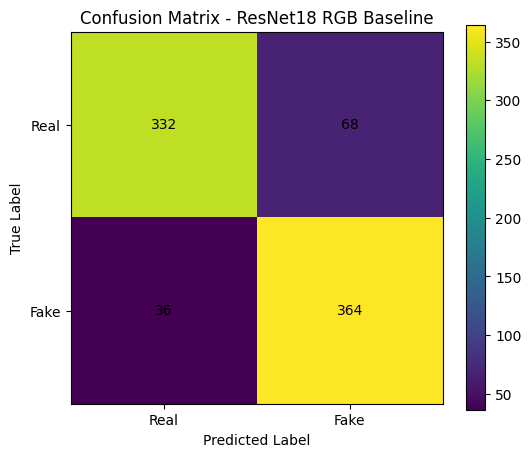

Confusion Matrix:
[[332  68]
 [ 36 364]]


In [22]:
# ============================================================
# 20. Confusion Matrix
# ============================================================

cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix - ResNet18 RGB Baseline")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["Real", "Fake"])
plt.yticks([0, 1], ["Real", "Fake"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

print("Confusion Matrix:")
print(cm)

# 10. Training History Visualization

Training and validation curves are plotted to analyze learning behavior.

These curves help identify whether the model is:

- Learning properly
- Underfitting
- Overfitting
- Improving steadily across epochs

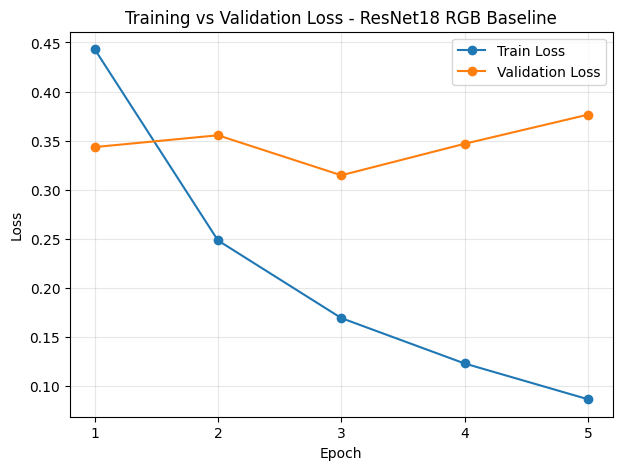

In [23]:
# ============================================================
# 21. Training and Validation Loss Curve
# ============================================================

epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
plt.title("Training vs Validation Loss - ResNet18 RGB Baseline")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(list(epochs))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

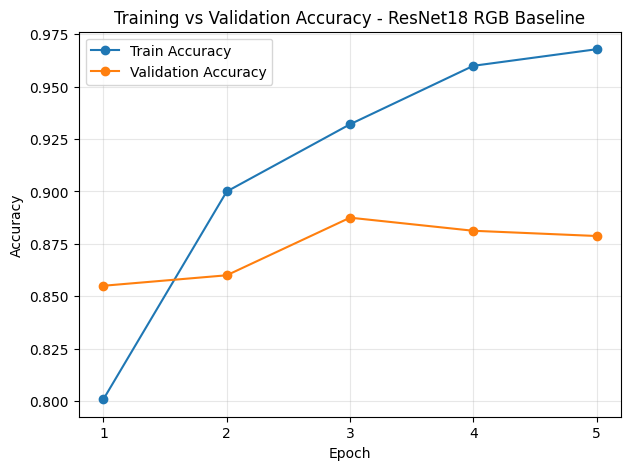

In [24]:
# ============================================================
# 22. Training and Validation Accuracy Curve
# ============================================================

plt.figure(figsize=(7, 5))
plt.plot(epochs, history["train_accuracy"], marker="o", label="Train Accuracy")
plt.plot(epochs, history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Training vs Validation Accuracy - ResNet18 RGB Baseline")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(list(epochs))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# 11. Save Baseline Results

The final test metrics are saved as a CSV file.

This file will be used later to compare the RGB baseline model with:

- Frequency-domain model
- Hybrid spatial-frequency model
- Ensemble models

In [25]:
# ============================================================
# 23. Save Baseline Results
# ============================================================

results = {
    "model": ["ResNet18_RGB_Baseline"],
    "input_type": ["RGB"],
    "best_val_accuracy": [best_val_accuracy],
    "test_accuracy": [test_accuracy],
    "test_precision": [test_precision],
    "test_recall": [test_recall],
    "test_f1_score": [test_f1],
    "test_loss": [test_loss],
    "epochs": [NUM_EPOCHS],
    "training_time_minutes": [training_time / 60]
}

results_df = pd.DataFrame(results)

results_path = "/kaggle/working/resnet18_rgb_baseline_results.csv"
results_df.to_csv(results_path, index=False)

print("Results saved successfully.")
print(results_df)

Results saved successfully.
                   model input_type  best_val_accuracy  test_accuracy  \
0  ResNet18_RGB_Baseline        RGB             0.8875           0.87   

   test_precision  test_recall  test_f1_score  test_loss  epochs  \
0        0.842593         0.91          0.875    0.33135       5   

   training_time_minutes  
0              14.070649  


In [26]:
# ============================================================
# 24. Save Training History
# ============================================================

history_df = pd.DataFrame(history)
history_df["epoch"] = range(1, NUM_EPOCHS + 1)

history_path = "/kaggle/working/resnet18_rgb_training_history.csv"
history_df.to_csv(history_path, index=False)

print("Training history saved successfully.")
print(history_df)

Training history saved successfully.
   train_loss  train_accuracy  val_loss  val_accuracy  epoch
0    0.443094        0.800833  0.343421       0.85500      1
1    0.248276        0.900000  0.355423       0.86000      2
2    0.169229        0.932083  0.314671       0.88750      3
3    0.122980        0.960000  0.346762       0.88125      4
4    0.086556        0.967917  0.376416       0.87875      5


In [28]:
import os

for file in os.listdir("/kaggle/working"):
    print(file)

.virtual_documents
best_resnet18_rgb_baseline.pth
resnet18_rgb_baseline_results.csv
resnet18_rgb_training_history.csv


# 12. Baseline Model Summary

The ResNet18 RGB baseline model was trained using only spatial-domain RGB image information.

## Key Observations

1. The model successfully learned discriminative features between real and AI-generated images.
2. The best validation accuracy was achieved before the final epoch, indicating slight overfitting in later epochs.
3. The saved best model was evaluated on the unseen test set.
4. Accuracy, precision, recall, F1-score, and confusion matrix were reported for a complete classification evaluation.

## Next Step

The next notebook will train a frequency-domain model using FFT magnitude spectrum images.

This will test whether frequency-domain artifacts provide useful information for detecting AI-generated images.

# 13. Result Interpretation

The ResNet18 RGB baseline achieved strong performance using only spatial-domain RGB image information.

## Final Test Performance

| Metric | Score |
|---|---:|
| Accuracy | 87.00% |
| Precision | 84.26% |
| Recall | 91.00% |
| F1-score | 87.50% |

## Confusion Matrix Interpretation

The test set contained 400 real images and 400 fake images.

| Actual Class | Correctly Classified | Misclassified |
|---|---:|---:|
| Real | 332 | 68 |
| Fake | 364 | 36 |

The model detected fake images better than real images.  
This is shown by the fake-class recall of 91.00%.

## Overfitting Observation

The model achieved its best validation accuracy at epoch 3.  
After epoch 3, the training accuracy continued to increase, but the validation accuracy decreased.

This indicates slight overfitting in later epochs.  
Therefore, the best validation checkpoint was used for final test evaluation.

## Baseline Conclusion

The RGB-based ResNet18 model provides a strong spatial-domain baseline.  
Future frequency-domain and hybrid spatial-frequency models will be compared against this result to determine whether frequency artifacts improve AI-generated image detection.